# PSGuard: Comparative Static Feature Analysis for Multi-Class PowerShell Malware Detection

## Dataset: das-lab/mpsd

### Classes
- Class 0 → Benign (`powershell_benign_dataset`)
- Class 1 → Pure Malicious (`malicious_pure`)
- Class 2 → Mixed Malicious (`mixed_malicious`)

## Pipeline Overview

1. **Dataset Loading & Statistics**
   - Load the MPSD dataset
   - Inspect class distribution and dataset statistics

2. **Script Preprocessing**
   - Clean and normalize PowerShell scripts
   - Prepare scripts for static feature extraction and transformer-based classification

3. **Stratified Train–Test Split**
   - Stratified 80:20 split
   - Fixed random seed
   - Feature-learning components are fitted using training data only

4. **Static Feature Extraction**
   - **Lexical Features**
   - **TF-IDF Features**
   - **Word2Vec Embeddings**

5. **Feature Configuration Ablation**
   - Seven configurations (C1–C7)
   - Individual and combined feature representations

6. **Classical Machine Learning**
   - Logistic Regression
   - Random Forest
   - LightGBM
   - 7 feature configurations × 3 classifiers = **21 experiments**

7. **Transformer Baseline**
   - Fine-tuned **CodeBERT** on preprocessed PowerShell scripts
   - Evaluated using the same held-out test set

8. **Model Evaluation**
   - Accuracy
   - Macro Precision
   - Macro Recall
   - Macro F1-score
   - One-vs-Rest ROC-AUC
   - Training time

9. **Five-Fold Stratified Cross-Validation**
   - All 7 feature configurations × 3 classifiers
   - 21 configurations × 5 folds = **105 model fits**
   - Feature-learning steps are refitted within each training fold to prevent leakage

10. **Statistical Significance Analysis**
    - McNemar's test
    - Best-performing classical model vs. CodeBERT
    - Same held-out test set

11. **Explainability Analysis**
    - SHAP analysis of the best-performing tree-based model
    - Global and class-specific feature importance

12. **Results & Visualization**
    - Complete 21-run results
    - Feature configuration comparison
    - Confusion matrix
    - SHAP visualizations
    - Computational performance
    - Cross-validation results
    - Statistical significance results

## 0. Imports & Configuration

In [1]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import re
import sys
import time
import warnings
import tracemalloc
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.sparse import hstack, csr_matrix, issparse

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing / Features ──────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from gensim.models import Word2Vec

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# ── Evaluation ────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
from statsmodels.stats.contingency_tables import mcnemar

# ── CodeBERT ──────────────────────────────────────────────────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH     = '/kaggle/input/datasets/adibamuttaqin/powershell-ds/ds'
BENIGN_DIR    = os.path.join(BASE_PATH, 'powershell_benign_dataset')
MALICIOUS_DIR = os.path.join(BASE_PATH, 'malicious_pure')
MIXED_DIR     = os.path.join(BASE_PATH, 'mixed_malicious')
OUTPUT_DIR    = '/kaggle/working'

CLASS_NAMES = {0: 'Benign', 1: 'Pure Malicious', 2: 'Mixed Malicious'}

print('All imports successful.')

All imports successful.


## ENVIRONMENT AUDIT

In [2]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
import platform, sklearn, scipy, gensim, lightgbm, transformers, shap as shap_lib

env_data = {
    'Platform'               : 'Kaggle Notebook',
    'Python'                 : sys.version.split()[0],
    'OS'                     : platform.platform(),
    'Random Seed'            : RANDOM_SEED,
    'NumPy'                  : np.__version__,
    'Pandas'                 : pd.__version__,
    'SciPy'                  : scipy.__version__,
    'scikit-learn'           : sklearn.__version__,
    'Gensim'                 : gensim.__version__,
    'LightGBM'               : lightgbm.__version__,
    'PyTorch'                : torch.__version__,
    'Transformers'           : transformers.__version__,
    'SHAP'                   : shap_lib.__version__,
    'CUDA Available'         : str(torch.cuda.is_available()),
    'GPU'                    : torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
    'CUDA Version'           : torch.version.cuda if torch.cuda.is_available() else 'N/A',
}

print('\n' + '='*50)
print('=== ENVIRONMENT REPORT ===')
print('='*50)
env_df = pd.DataFrame(list(env_data.items()), columns=['Setting', 'Value'])
print(env_df.to_string(index=False))
env_df.to_csv(os.path.join(OUTPUT_DIR, 'environment_report.csv'), index=False)


=== ENVIRONMENT REPORT ===
       Setting                                Value
      Platform                      Kaggle Notebook
        Python                              3.12.13
            OS Linux-6.12.90+-x86_64-with-glibc2.35
   Random Seed                                   42
         NumPy                                2.0.2
        Pandas                                2.3.3
         SciPy                               1.16.3
  scikit-learn                                1.6.1
        Gensim                                4.4.0
      LightGBM                                4.6.0
       PyTorch                         2.10.0+cu128
  Transformers                                5.0.0
          SHAP                               0.51.0
CUDA Available                                 True
           GPU                             Tesla T4
  CUDA Version                                 12.8


---
## Step 1 — Dataset Loading & Statistics


Loading dataset …
  Loaded  4316 files  ←  powershell_benign_dataset
  Loaded  4202 files  ←  malicious_pure
  Loaded  4202 files  ←  mixed_malicious

DataFrame shape : (12720, 3)
Max/Min class ratio: 1.027
Dataset is approximately balanced.
Empty scripts  : 0


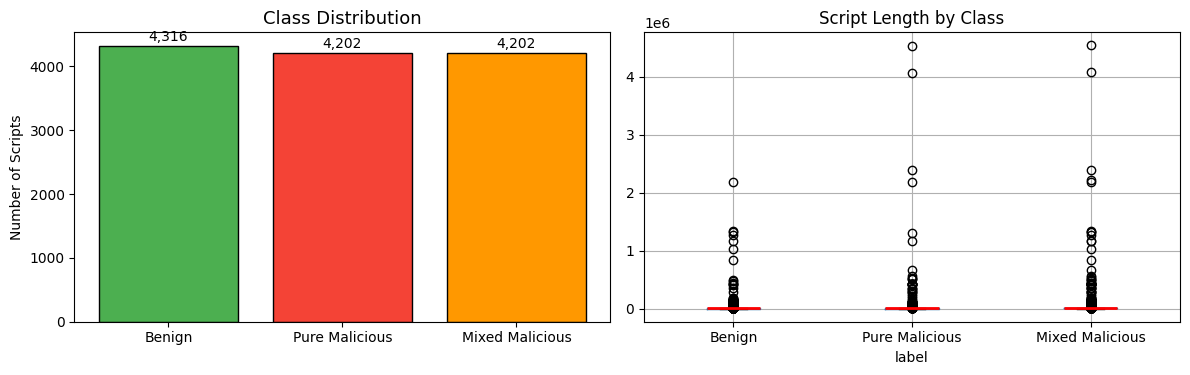

In [3]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
def load_scripts(folder: str, label: int) -> list:
    records = []
    if not os.path.exists(folder):
        print(f'[WARNING] Folder not found: {folder}')
        return records
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.endswith('.ps1'):
                fpath = os.path.join(root, fname)
                with open(fpath, 'r', errors='ignore') as fh:
                    records.append({'raw_text': fh.read(), 'label': label})
    print(f'  Loaded {len(records):>5d} files  ←  {os.path.basename(folder)}')
    return records

print('\nLoading dataset …')
df = pd.DataFrame(
    load_scripts(BENIGN_DIR, 0) +
    load_scripts(MALICIOUS_DIR, 1) +
    load_scripts(MIXED_DIR, 2)
)

df['script_length'] = df['raw_text'].str.len()

counts = df['label'].value_counts()
print(f'\nDataFrame shape : {df.shape}')
print(f'Max/Min class ratio: {counts.max()/counts.min():.3f}')
print('Dataset is approximately balanced.')
print(f'Empty scripts  : {(df["raw_text"].str.strip() == "").sum()}')

# ── Dataset statistics figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(
    [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)],
    [counts[i] for i in sorted(CLASS_NAMES)],
    color=['#4CAF50', '#F44336', '#FF9800'], edgecolor='black'
)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Scripts')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)
df.boxplot(column='script_length', by='label', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Script Length by Class')
axes[1].set_xticklabels([CLASS_NAMES[i] for i in sorted(CLASS_NAMES)])
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'step1_distribution.png'), dpi=150)
plt.show()

---
## Step 2 — Preprocessing

In [4]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
IP_PATTERN    = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
URL_PATTERN   = re.compile(r'https?://\S+|www\.\S+')
ASCII_PATTERN = re.compile(r'[^\x00-\x7F]+')

def preprocess(text: str) -> str:
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = URL_PATTERN.sub('<url>', text)
    text = IP_PATTERN.sub('<ip>', text)
    text = ASCII_PATTERN.sub('', text)
    return text

print('\nPreprocessing …')
df['clean_text'] = df['raw_text'].apply(preprocess)
print(f'Empty scripts after preprocessing: {(df["clean_text"].str.strip() == "").sum()}')


Preprocessing …
Empty scripts after preprocessing: 0


---
## Step 3 — Feature Extraction: Branch A (Lexical & Statistical)

In [5]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
SECURITY_KEYWORDS = [
    'iex', 'invoke-expression', 'encodedcommand', 'bypass', 'nop',
    'downloadstring', 'frombase64string', 'webclient', 'windowstyle'
]
LEX_FEATURE_NAMES = ['entropy', 'char_count', 'line_count',
                     'token_count', 'special_ratio', 'kw_frequency']

def shannon_entropy(text: str) -> float:
    if not text:
        return 0.0
    freq = pd.Series(list(text)).value_counts(normalize=True)
    return float(-(freq * np.log2(freq + 1e-12)).sum())

def special_char_ratio(text: str) -> float:
    if not text:
        return 0.0
    return sum(1 for c in text if not c.isalnum() and not c.isspace()) / len(text)

def keyword_frequency(text: str) -> int:
    return sum(text.count(kw) for kw in SECURITY_KEYWORDS)

def extract_lexical(texts) -> np.ndarray:
    series = pd.Series(texts) if not isinstance(texts, pd.Series) else texts
    df_tmp = pd.DataFrame({'t': series})
    feats = pd.DataFrame({
        'entropy'      : df_tmp['t'].apply(shannon_entropy),
        'char_count'   : df_tmp['t'].str.len(),
        'line_count'   : df_tmp['t'].str.count('\n') + 1,
        'token_count'  : df_tmp['t'].str.split().str.len(),
        'special_ratio': df_tmp['t'].apply(special_char_ratio),
        'kw_frequency' : df_tmp['t'].apply(keyword_frequency),
    })
    return feats.values.astype(np.float32)

print('\nExtracting lexical features …')
X_lex_raw = extract_lexical(df['clean_text'])
print(f'Lexical matrix shape: {X_lex_raw.shape}')

# ── Feature extraction timing & memory ───────────────────────────────────────
def measure(fn, *args):
    tracemalloc.start()
    t0 = time.time()
    r = fn(*args)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return elapsed, peak / 1024**2, r

t_lex, mem_lex, _ = measure(extract_lexical, df['clean_text'])


Extracting lexical features …
Lexical matrix shape: (12720, 6)


---
## STEP 4 — STRATIFIED 80/20 TRAIN-TEST SPLIT

In [6]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 4 — STRATIFIED 80/20 TRAIN-TEST SPLIT
# Moved BEFORE TF-IDF/Word2Vec fitting to prevent primary leakage.
# Split happens on the raw dataset; TF-IDF and Word2Vec below are fit
# ONLY on the resulting training partition.
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =

y       = df['label'].values
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print(f'\nTrain: {len(train_idx):,}  |  Test: {len(test_idx):,}')

# Scale lexical features on train only (unchanged — lexical was already leakage-free)
scaler      = StandardScaler()
X_lex_train = scaler.fit_transform(X_lex_raw[train_idx])
X_lex_test  = scaler.transform(X_lex_raw[test_idx])

y_train = y[train_idx]
y_test  = y[test_idx]

# Text splits — used below to fit TF-IDF/Word2Vec on TRAINING data only,
# and also used as-is (full corpus) by the separate CV loop in STEP 11,
# which performs its own independent per-fold fitting.
texts_all       = df['clean_text'].values
train_texts_raw = texts_all[train_idx]
test_texts_raw  = texts_all[test_idx]


Train: 10,176  |  Test: 2,544


---
## Step 5 — Feature Extraction: Branch B (TF-IDF N-grams)

In [7]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 5 — TF-IDF (Branch B)
# LEAKAGE FIX: TF-IDF is now fit ONLY on the training partition.
# The test partition is transformed using the train-fitted vectorizer.
# CV (STEP 11) already refits TF-IDF per fold on training data only.

# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
print('\nFitting TF-IDF vectorizer on TRAINING data only …')
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), max_features=5000,
    sublinear_tf=True, analyzer='word',
    token_pattern=r'(?u)\b\w+\b'
)
X_tfidf_train = tfidf_vectorizer.fit_transform(train_texts_raw)
X_tfidf_test  = tfidf_vectorizer.transform(test_texts_raw)
TFIDF_FEATURE_NAMES = tfidf_vectorizer.get_feature_names_out()
print(f'TF-IDF train shape: {X_tfidf_train.shape}  |  test shape: {X_tfidf_test.shape}')

tfidf_tmp = TfidfVectorizer(ngram_range=(1,2), max_features=5000,
                             sublinear_tf=True, token_pattern=r'(?u)\b\w+\b')
t_tfidf, mem_tfidf, _ = measure(tfidf_tmp.fit_transform, train_texts_raw)


Fitting TF-IDF vectorizer on TRAINING data only …
TF-IDF train shape: (10176, 5000)  |  test shape: (2544, 5000)


---
## Step 6 — Feature Extraction: Branch C (Word2Vec Embeddings)

In [8]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 6 — WORD2VEC (Branch C)
# LEAKAGE FIX: Word2Vec is now trained ONLY on the training corpus.
# Test vectors are pooled using embeddings from this same train-fitted model.
# CV (STEP 11) already retrains Word2Vec per fold on training data only.

# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
print('\nTraining Word2Vec on TRAINING data only …')
train_tokenized = [t.split() for t in train_texts_raw]
test_tokenized  = [t.split() for t in test_texts_raw]

w2v_model = Word2Vec(
    sentences=train_tokenized, vector_size=100,
    window=5, min_count=1, workers=4, epochs=10, seed=RANDOM_SEED
)

def mean_pool_w2v(tokens, model, dim=100):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v_train = np.vstack([mean_pool_w2v(t, w2v_model) for t in train_tokenized]).astype(np.float32)
X_w2v_test  = np.vstack([mean_pool_w2v(t, w2v_model) for t in test_tokenized]).astype(np.float32)
print(f'Word2Vec train shape: {X_w2v_train.shape}  |  test shape: {X_w2v_test.shape}')

def fit_w2v_and_pool(corpus):
    m = Word2Vec(sentences=corpus, vector_size=100, window=5,
                 min_count=1, workers=4, epochs=10, seed=RANDOM_SEED)
    return np.vstack([mean_pool_w2v(t, m) for t in corpus])

t_w2v, mem_w2v, _ = measure(fit_w2v_and_pool, train_tokenized)

# ── Feature extraction report (measured on training-fold fitting) ────────────
feat_cost_df = pd.DataFrame([
    {'Feature': 'Lexical',          'Dimensionality': 6,    'Extraction_s': round(t_lex,   2), 'Peak_MB': round(mem_lex,   1)},
    {'Feature': 'TF-IDF',           'Dimensionality': 5000, 'Extraction_s': round(t_tfidf, 2), 'Peak_MB': round(mem_tfidf, 1)},
    {'Feature': 'Word2Vec',          'Dimensionality': 100,  'Extraction_s': round(t_w2v,   2), 'Peak_MB': round(mem_w2v,   1)},
    {'Feature': 'All Three Combined','Dimensionality': 5106, 'Extraction_s': round(t_lex+t_tfidf+t_w2v, 2), 'Peak_MB': round(mem_lex+mem_tfidf+mem_w2v, 1)},
])
print('\n== Feature Extraction Cost ==')
print(feat_cost_df.to_string(index=False))
feat_cost_df.to_csv(os.path.join(OUTPUT_DIR, 'feature_extraction_timing.csv'), index=False)


Training Word2Vec on TRAINING data only …
Word2Vec train shape: (10176, 100)  |  test shape: (2544, 100)

== Feature Extraction Cost ==
           Feature  Dimensionality  Extraction_s  Peak_MB
           Lexical               6        162.91    316.0
            TF-IDF            5000         80.21    499.5
          Word2Vec             100        117.71    208.0
All Three Combined            5106        360.83   1023.5


---
## Step 7 — Feature Configurations (Ablation Design)

In [9]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 7 — FEATURE CONFIGURATIONS (C1-C7)
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
def combine(parts_train, parts_test):
    def sp(m): return m if issparse(m) else csr_matrix(m)
    return hstack([sp(p) for p in parts_train]), hstack([sp(p) for p in parts_test])

feature_configs = {
    'C1 Lexical'            : combine([X_lex_train],                             [X_lex_test]),
    'C2 TF-IDF'             : combine([X_tfidf_train],                           [X_tfidf_test]),
    'C3 Word2Vec'           : combine([X_w2v_train],                             [X_w2v_test]),
    'C4 Lex+TF-IDF'         : combine([X_lex_train, X_tfidf_train],             [X_lex_test, X_tfidf_test]),
    'C5 Lex+Word2Vec'       : combine([X_lex_train, X_w2v_train],               [X_lex_test, X_w2v_test]),
    'C6 TF-IDF+Word2Vec'    : combine([X_tfidf_train, X_w2v_train],             [X_tfidf_test, X_w2v_test]),
    'C7 All Three'          : combine([X_lex_train, X_tfidf_train, X_w2v_train],[X_lex_test, X_tfidf_test, X_w2v_test]),
}

# Map C-keys to readable names for the paper
CONFIG_LABELS = {
    'C1 Lexical'        : 'Lexical',
    'C2 TF-IDF'         : 'TF-IDF',
    'C3 Word2Vec'       : 'Word2Vec',
    'C4 Lex+TF-IDF'     : 'Lexical + TF-IDF',
    'C5 Lex+Word2Vec'   : 'Lexical + Word2Vec',
    'C6 TF-IDF+Word2Vec': 'TF-IDF + Word2Vec',
    'C7 All Three'      : 'All Three Combined',
}

print('\nFeature configurations:')
for name, (tr, te) in feature_configs.items():
    print(f'  {name:<20}  train={tr.shape}  test={te.shape}')


Feature configurations:
  C1 Lexical            train=(10176, 6)  test=(2544, 6)
  C2 TF-IDF             train=(10176, 5000)  test=(2544, 5000)
  C3 Word2Vec           train=(10176, 100)  test=(2544, 100)
  C4 Lex+TF-IDF         train=(10176, 5006)  test=(2544, 5006)
  C5 Lex+Word2Vec       train=(10176, 106)  test=(2544, 106)
  C6 TF-IDF+Word2Vec    train=(10176, 5100)  test=(2544, 5100)
  C7 All Three          train=(10176, 5106)  test=(2544, 5106)


---
## STEP 8a — PRIMARY 21-RUN EXPERIMENT

In [10]:
# STEP 8 — PRIMARY 21-RUN EXPERIMENT

# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    'LightGBM'           : lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1),
}

def evaluate_model(model, X_tr, X_te, y_tr, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)
    return {
        'Accuracy'        : round(accuracy_score(y_te, y_pred), 4),
        'Macro Precision' : round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Macro Recall'    : round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'Macro F1'        : round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4),
        'OvR AUC'         : round(roc_auc_score(y_te, y_prob, multi_class='ovr', average='macro'), 4),
        'Train Time (s)'  : round(train_time, 2),
        '_model'          : model,
        '_y_pred'         : y_pred,
        '_y_prob'         : y_prob,
    }

print('\n' + '='*60)
print('PRIMARY 21-RUN EXPERIMENT')
print('='*60)

primary_results = []
best_f1    = -1
best_info  = {}
total_runs = len(models) * len(feature_configs)
exp_num    = 0

for cfg_key, (X_tr, X_te) in feature_configs.items():
    for model_name, model_proto in models.items():
        exp_num += 1
        m = clone(model_proto)
        print(f'[{exp_num:02d}/{total_runs}] {model_name:<22} | {cfg_key} … ', end='')
        metrics = evaluate_model(m, X_tr, X_te, y_train, y_test)
        row = {
            'Configuration' : CONFIG_LABELS[cfg_key],
            'Config Key'    : cfg_key,
            'Model'         : model_name,
            **{k: v for k, v in metrics.items() if not k.startswith('_')}
        }
        primary_results.append(row)
        print(f"F1={metrics['Macro F1']:.4f}  AUC={metrics['OvR AUC']:.4f}  {metrics['Train Time (s)']}s")
        if metrics['Macro F1'] > best_f1:
            best_f1 = metrics['Macro F1']
            best_info = {
                'model_name' : model_name,
                'cfg_key'    : cfg_key,
                'cfg_label'  : CONFIG_LABELS[cfg_key],
                'model'      : m,
                'X_train'    : X_tr,
                'X_test'     : X_te,
                'y_pred'     : metrics['_y_pred'],
                'y_prob'     : metrics['_y_prob'],
            }

primary_df = pd.DataFrame(primary_results)
primary_df_sorted = primary_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '='*50)
print('=== PRIMARY 21-RUN RESULTS ===')
print('='*50)
print(primary_df_sorted[['Configuration','Model','Accuracy','Macro Precision',
                           'Macro Recall','Macro F1','OvR AUC','Train Time (s)']].to_string(index=False))

print('\n' + '='*50)
print('=== PRIMARY BEST MODEL ===')
print('='*50)
print(f"  Model         : {best_info['model_name']}")
print(f"  Configuration : {best_info['cfg_label']}")
print(f"  Macro F1      : {best_f1:.4f}")

primary_df_sorted.to_csv(os.path.join(OUTPUT_DIR, 'primary_21_results.csv'), index=False)

# Best model per classifier
best_per_clf = (
    primary_df.sort_values('Macro F1', ascending=False)
    .groupby('Model').first().reset_index()
    [['Model','Configuration','Accuracy','Macro F1','OvR AUC','Train Time (s)']]
)
print('\n== BEST MODEL PER CLASSIFIER ==')
print(best_per_clf.to_string(index=False))
best_per_clf.to_csv(os.path.join(OUTPUT_DIR, 'best_model_per_classifier.csv'), index=False)


PRIMARY 21-RUN EXPERIMENT
[01/21] Logistic Regression    | C1 Lexical … F1=0.7240  AUC=0.8594  1.6s
[02/21] Random Forest          | C1 Lexical … F1=0.9132  AUC=0.9778  1.51s
[03/21] LightGBM               | C1 Lexical … F1=0.9122  AUC=0.9797  0.77s
[04/21] Logistic Regression    | C2 TF-IDF … F1=0.9399  AUC=0.9913  2.25s
[05/21] Random Forest          | C2 TF-IDF … F1=0.9617  AUC=0.9962  3.83s
[06/21] LightGBM               | C2 TF-IDF … F1=0.9759  AUC=0.9985  51.09s
[07/21] Logistic Regression    | C3 Word2Vec … F1=0.8395  AUC=0.9510  4.1s
[08/21] Random Forest          | C3 Word2Vec … F1=0.7306  AUC=0.8757  8.71s
[09/21] LightGBM               | C3 Word2Vec … F1=0.7701  AUC=0.9173  4.08s
[10/21] Logistic Regression    | C4 Lex+TF-IDF … F1=0.9426  AUC=0.9898  4.17s
[11/21] Random Forest          | C4 Lex+TF-IDF … F1=0.9650  AUC=0.9967  3.51s
[12/21] LightGBM               | C4 Lex+TF-IDF … F1=0.9780  AUC=0.9982  45.06s
[13/21] Logistic Regression    | C5 Lex+Word2Vec … F1=0.8619  AU

---
## STEP 8b — PRIMARY RESULTS FIGURE

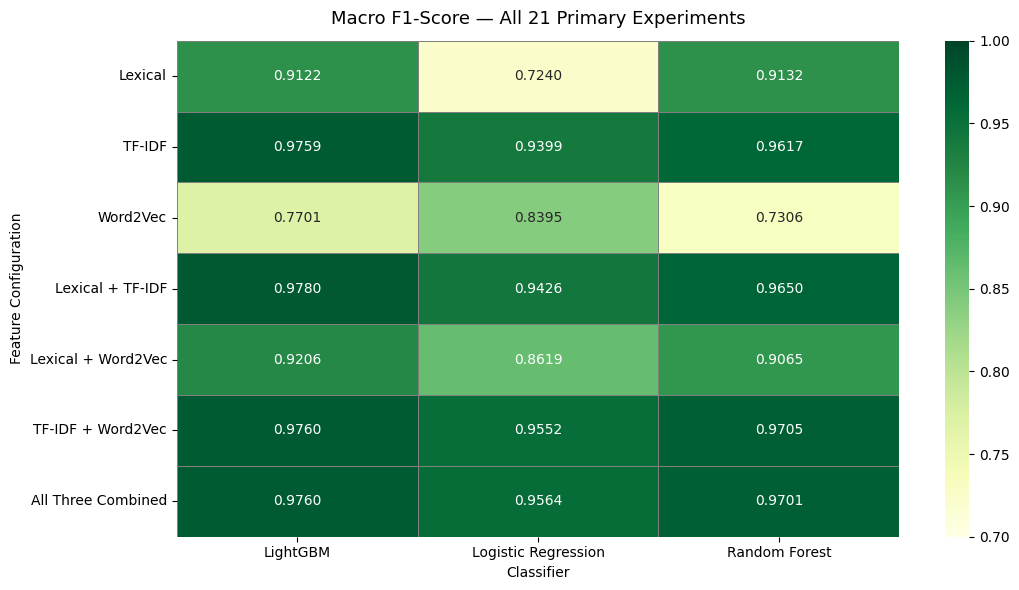

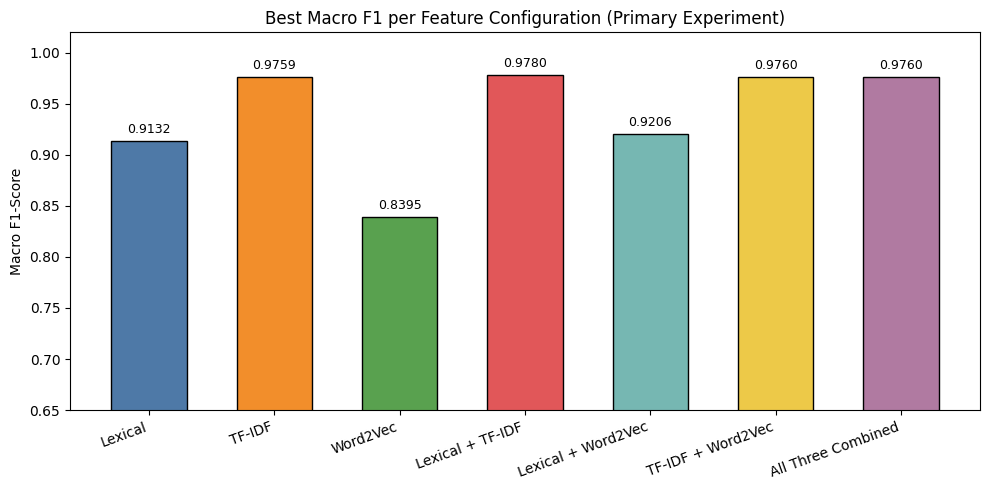

In [11]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
pivot = primary_df.pivot_table(index='Configuration', columns='Model',
                                values='Macro F1', aggfunc='first')
pivot = pivot.loc[[CONFIG_LABELS[k] for k in feature_configs.keys()]]

plt.figure(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, linecolor='grey', vmin=0.7, vmax=1.0)
plt.title('Macro F1-Score — All 21 Primary Experiments', fontsize=13, pad=12)
plt.ylabel('Feature Configuration')
plt.xlabel('Classifier')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'primary_21_macro_f1_comparison.png'), dpi=200)
plt.show()

# Bar chart per config (best model each)
ablation = (
    primary_df.sort_values('Macro F1', ascending=False)
    .groupby('Configuration').first().reset_index()
)
cfg_order = [CONFIG_LABELS[k] for k in feature_configs.keys()]
ablation['Configuration'] = pd.Categorical(ablation['Configuration'],
                                            categories=cfg_order, ordered=True)
ablation = ablation.sort_values('Configuration')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4e79a7','#f28e2b','#59a14f','#e15759','#76b7b2','#edc948','#b07aa1']
bars = ax.bar(ablation['Configuration'], ablation['Macro F1'],
              color=colors, edgecolor='black', width=0.6)
ax.set_ylim(0.65, 1.02)
ax.set_ylabel('Macro F1-Score')
ax.set_title('Best Macro F1 per Feature Configuration (Primary Experiment)')
ax.set_xticklabels(ablation['Configuration'], rotation=20, ha='right')
for bar, val in zip(bars, ablation['Macro F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_configuration_macro_f1_comparison.png'), dpi=200)
plt.show()

---
## STEP 8c — CONFUSION MATRIX (best primary classical model)

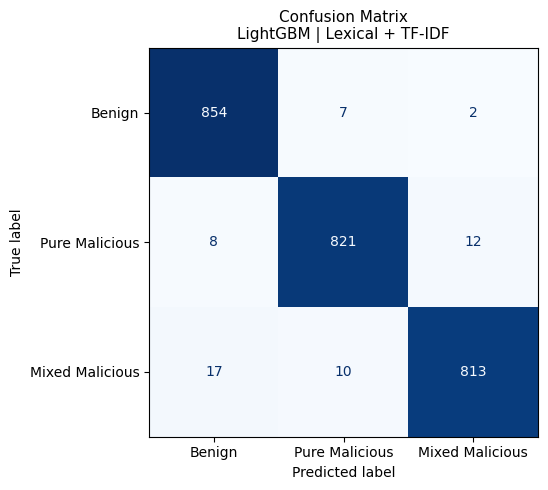


== CONFUSION MATRIX ==
                      Pred Benign  Pred Pure Malicious  Pred Mixed Malicious
True Benign                   854                    7                     2
True Pure Malicious             8                  821                    12
True Mixed Malicious           17                   10                   813

                 precision    recall  f1-score   support

         Benign       0.97      0.99      0.98       863
 Pure Malicious       0.98      0.98      0.98       841
Mixed Malicious       0.98      0.97      0.98       840

       accuracy                           0.98      2544
      macro avg       0.98      0.98      0.98      2544
   weighted avg       0.98      0.98      0.98      2544



In [12]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 8c — CONFUSION MATRIX (best primary classical model)
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
cm = confusion_matrix(y_test, best_info['y_pred'])
cm_df = pd.DataFrame(cm,
    index  =[f'True {CLASS_NAMES[i]}' for i in range(3)],
    columns=[f'Pred {CLASS_NAMES[i]}' for i in range(3)]
)
cm_df.to_csv(os.path.join(OUTPUT_DIR, 'confusion_matrix.csv'))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=[CLASS_NAMES[i] for i in range(3)])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix\n{best_info["model_name"]} | {best_info["cfg_label"]}',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_best_classical.png'), dpi=200)
plt.show()

print('\n== CONFUSION MATRIX ==')
print(cm_df)
print()
print(classification_report(y_test, best_info['y_pred'],
      target_names=[CLASS_NAMES[i] for i in range(3)]))

---
## STEP 9 — CODEBERT BASELINE 

In [13]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 9 — CODEBERT BASELINE (unchanged from original)
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'microsoft/codebert-base'
MAX_LEN    = 512
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5
NUM_LABELS = 3

class PSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc    = tokenizer(list(texts), truncation=True, padding='max_length',
                                max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.enc.items()}, self.labels[idx]

print(f'\nCodeBERT — device: {DEVICE}')
tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)

train_texts = df['clean_text'].iloc[train_idx].values
test_texts  = df['clean_text'].iloc[test_idx].values

train_ds = PSDataset(train_texts, y_train, tokenizer_bert, MAX_LEN)
test_ds  = PSDataset(test_texts,  y_test,  tokenizer_bert, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, ignore_mismatched_sizes=True).to(DEVICE)

optimizer   = AdamW(bert_model.parameters(), lr=LR)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps)

bert_t0 = time.time()
for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0
    for batch_enc, batch_lbl in train_dl:
        batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
        batch_lbl = batch_lbl.to(DEVICE)
        optimizer.zero_grad()
        out  = bert_model(**batch_enc, labels=batch_lbl)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    print(f'  Epoch {epoch+1}/{EPOCHS}  avg_loss={total_loss/len(train_dl):.4f}')

bert_train_time = time.time() - bert_t0

bert_model.eval()
bert_preds, bert_probs = [], []
with torch.no_grad():
    for batch_enc, _ in test_dl:
        batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
        logits = bert_model(**batch_enc).logits
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        bert_probs.append(probs)
        bert_preds.extend(probs.argmax(axis=1))

bert_probs = np.vstack(bert_probs)
bert_preds = np.array(bert_preds)

bert_metrics = {
    'Accuracy'        : round(accuracy_score(y_test, bert_preds), 4),
    'Macro Precision' : round(precision_score(y_test, bert_preds, average='macro', zero_division=0), 4),
    'Macro Recall'    : round(recall_score(y_test, bert_preds, average='macro', zero_division=0), 4),
    'Macro F1'        : round(f1_score(y_test, bert_preds, average='macro'), 4),
    'OvR AUC'         : round(roc_auc_score(y_test, bert_probs, multi_class='ovr', average='macro'), 4),
}

print('\n' + '='*50)
print('=== CODEBERT RESULTS ===')
print('='*50)
print(f"  Model      : {MODEL_NAME}")
for k, v in bert_metrics.items():
    print(f'  {k:<20}: {v}')
print(f'  Train Time : {bert_train_time:.1f}s (GPU)')
print()
print(classification_report(y_test, bert_preds,
      target_names=[CLASS_NAMES[i] for i in range(3)]))

# Comparison table
comp_df = pd.DataFrame([
    {'Model': f"{best_info['model_name']} ({best_info['cfg_label']})",
     'Type' : 'Classical ML (Best)',
     'Accuracy': primary_df_sorted.iloc[0]['Accuracy'],
     'Macro Precision': primary_df_sorted.iloc[0]['Macro Precision'],
     'Macro Recall': primary_df_sorted.iloc[0]['Macro Recall'],
     'Macro F1': primary_df_sorted.iloc[0]['Macro F1'],
     'OvR AUC': primary_df_sorted.iloc[0]['OvR AUC'],
     'Train Time': f"{primary_df_sorted.iloc[0]['Train Time (s)']}s (CPU)"},
    {'Model': MODEL_NAME,
     'Type' : 'Transformer Baseline',
     **bert_metrics,
     'Train Time': f'{bert_train_time:.1f}s (GPU)'},
])
comp_df.to_csv(os.path.join(OUTPUT_DIR, 'best_classical_vs_codebert.csv'), index=False)

print('== BEST CLASSICAL vs CODEBERT ==')
print(comp_df.to_string(index=False))


CodeBERT — device: cuda


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3  avg_loss=0.5285
  Epoch 2/3  avg_loss=0.3754
  Epoch 3/3  avg_loss=0.3538

=== CODEBERT RESULTS ===
  Model      : microsoft/codebert-base
  Accuracy            : 0.7433
  Macro Precision     : 0.8133
  Macro Recall        : 0.7471
  Macro F1            : 0.7187
  OvR AUC             : 0.9022
  Train Time : 3499.5s (GPU)

                 precision    recall  f1-score   support

         Benign       0.89      0.31      0.46       863
 Pure Malicious       0.98      0.97      0.98       841
Mixed Malicious       0.57      0.95      0.71       840

       accuracy                           0.74      2544
      macro avg       0.81      0.75      0.72      2544
   weighted avg       0.81      0.74      0.72      2544

== BEST CLASSICAL vs CODEBERT ==
                      Model                 Type  Accuracy  Macro Precision  Macro Recall  Macro F1  OvR AUC    Train Time
LightGBM (Lexical + TF-IDF)  Classical ML (Best)    0.9780           0.9781        0.9779    0.9780   0.9

---
## STEP 10 — MCNEMAR'S TEST (best classical vs CodeBERT)

In [14]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 10 — MCNEMAR'S TEST (best classical vs CodeBERT — CORRECTED)
# Uses the SAME held-out 20% test set. NOT CV averages.
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =

# Identify best classical model prediction on held-out test set
best_classical_pred = best_info['y_pred']  # from primary 21-run experiment

correct_classical = (best_classical_pred == y_test)
correct_bert      = (bert_preds          == y_test)

b = int(np.sum( correct_classical & ~correct_bert))  # classical right, bert wrong
c = int(np.sum(~correct_classical &  correct_bert))  # classical wrong, bert right

contingency = [
    [int(np.sum(correct_classical &  correct_bert)),  c],
    [b, int(np.sum(~correct_classical & ~correct_bert))]
]

mcnemar_result = mcnemar(contingency, exact=False, correction=True)

mcnemar_data = {
    'Model 1'           : f"{best_info['model_name']} ({best_info['cfg_label']})",
    'Model 2'           : MODEL_NAME,
    'b (M1 right M2 wrong)' : b,
    'c (M1 wrong M2 right)' : c,
    'Chi-squared'       : round(mcnemar_result.statistic, 4),
    'p-value'           : round(mcnemar_result.pvalue, 6),
    'Alpha'             : 0.05,
    'Decision'          : 'Significant' if mcnemar_result.pvalue < 0.05 else 'Not Significant',
}

print('\n' + '='*50)
print('=== MCNEMAR TEST ===')
print('='*50)
for k, v in mcnemar_data.items():
    print(f'  {k:<30}: {v}')

pd.DataFrame([mcnemar_data]).to_csv(
    os.path.join(OUTPUT_DIR, 'mcnemar_results.csv'), index=False)


=== MCNEMAR TEST ===
  Model 1                       : LightGBM (Lexical + TF-IDF)
  Model 2                       : microsoft/codebert-base
  b (M1 right M2 wrong)         : 623
  c (M1 wrong M2 right)         : 26
  Chi-squared                   : 547.3282
  p-value                       : 0.0
  Alpha                         : 0.05
  Decision                      : Significant


---
## STEP 11 — FULL 5-FOLD CV ON ALL 21 EXPERIMENTS (7 configs × 3 classifiers)

In [15]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 11 — FULL 5-FOLD CV ON ALL 21 EXPERIMENTS (7 configs × 3 classifiers)
# LEAKAGE HANDLING:
#   - Lexical features: handcrafted, no fitting needed. StandardScaler fitted
#     per fold on train partition only.
#   - TF-IDF: refitted per fold on train texts only (avoids vocabulary leakage).
#   - Word2Vec: retrained per fold on train texts only.
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
CV_FOLDS      = 5
CV_CHECKPOINT = os.path.join(OUTPUT_DIR, 'cv_checkpoint_results.csv')

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Load checkpoint if exists (for Kaggle session safety)
completed_keys = set()
cv_rows_all    = []

if os.path.exists(CV_CHECKPOINT):
    ck = pd.read_csv(CV_CHECKPOINT)
    cv_rows_all = ck.to_dict('records')
    completed_keys = set(zip(ck['Config Key'], ck['Model'], ck['Fold']))
    print(f'[RESUME] Loaded {len(cv_rows_all)} rows from checkpoint.')

# Config spec: which raw feature families to use per fold
# We rebuild features inside each fold to prevent leakage.
TFIDF_PARAMS = dict(ngram_range=(1,2), max_features=5000,
                    sublinear_tf=True, token_pattern=r'(?u)\b\w+\b')
W2V_PARAMS   = dict(vector_size=100, window=5, min_count=1,
                    workers=4, epochs=10, seed=RANDOM_SEED)

# Which feature families each config uses
CONFIG_SPEC = {
    'C1 Lexical'        : ('lex',),
    'C2 TF-IDF'         : ('tfidf',),
    'C3 Word2Vec'        : ('w2v',),
    'C4 Lex+TF-IDF'     : ('lex', 'tfidf'),
    'C5 Lex+Word2Vec'   : ('lex', 'w2v'),
    'C6 TF-IDF+Word2Vec': ('tfidf', 'w2v'),
    'C7 All Three'      : ('lex', 'tfidf', 'w2v'),
}

total_cv = len(CONFIG_SPEC) * len(models) * CV_FOLDS
done_cv  = 0
t_cv_start = time.time()

print(f'\n{"="*60}')
print(f'FULL 5-FOLD CV: {len(CONFIG_SPEC)} configs × {len(models)} models × {CV_FOLDS} folds = {total_cv} fits')
print('='*60)

all_texts = df['clean_text'].values  # full corpus for per-fold fitting

for cfg_key, families in CONFIG_SPEC.items():
    cfg_label = CONFIG_LABELS[cfg_key]

    for model_name, model_proto in models.items():
        fold_scores = []

        for fold_i, (tr_idx, te_idx) in enumerate(skf.split(np.arange(len(df)), y), 1):
            done_cv += 1

            # Skip if already checkpointed
            if (cfg_key, model_name, fold_i) in completed_keys:
                print(f'  [SKIP] {cfg_key} | {model_name} | Fold {fold_i} (checkpointed)')
                continue

            t_fold = time.time()

            # ── Build fold-safe feature matrices ──────────────────────────────
            parts_train, parts_test = [], []

            if 'lex' in families:
                X_lex_fold_raw = extract_lexical(all_texts[tr_idx])
                X_lex_fold_te  = extract_lexical(all_texts[te_idx])
                fold_scaler    = StandardScaler()
                X_lex_tr_s     = fold_scaler.fit_transform(X_lex_fold_raw)
                X_lex_te_s     = fold_scaler.transform(X_lex_fold_te)
                parts_train.append(csr_matrix(X_lex_tr_s))
                parts_test.append( csr_matrix(X_lex_te_s))

            if 'tfidf' in families:
                fold_tfidf = TfidfVectorizer(**TFIDF_PARAMS)
                X_tf_tr = fold_tfidf.fit_transform(all_texts[tr_idx])
                X_tf_te = fold_tfidf.transform(all_texts[te_idx])
                parts_train.append(X_tf_tr)
                parts_test.append( X_tf_te)

            if 'w2v' in families:
                fold_corpus_tr = [t.split() for t in all_texts[tr_idx]]
                fold_corpus_te = [t.split() for t in all_texts[te_idx]]
                fold_w2v = Word2Vec(sentences=fold_corpus_tr, **W2V_PARAMS)
                X_w2v_tr = np.vstack([mean_pool_w2v(t, fold_w2v) for t in fold_corpus_tr]).astype(np.float32)
                X_w2v_te = np.vstack([mean_pool_w2v(t, fold_w2v) for t in fold_corpus_te]).astype(np.float32)
                parts_train.append(csr_matrix(X_w2v_tr))
                parts_test.append( csr_matrix(X_w2v_te))

            X_fold_tr = hstack(parts_train)
            X_fold_te = hstack(parts_test)

            # ── Train & evaluate ──────────────────────────────────────────────
            m = clone(model_proto)
            try:
                t0_m = time.time()
                m.fit(X_fold_tr, y[tr_idx])
                fold_train_t = round(time.time() - t0_m, 2)
                y_fold_pred = m.predict(X_fold_te)
                y_fold_prob = m.predict_proba(X_fold_te)
                fold_f1  = round(f1_score(y[te_idx], y_fold_pred, average='macro'), 4)
                fold_acc = round(accuracy_score(y[te_idx], y_fold_pred), 4)
                fold_pr  = round(precision_score(y[te_idx], y_fold_pred, average='macro', zero_division=0), 4)
                fold_re  = round(recall_score(y[te_idx], y_fold_pred, average='macro', zero_division=0), 4)
                fold_auc = round(roc_auc_score(y[te_idx], y_fold_prob, multi_class='ovr', average='macro'), 4)
                warn_flag = ''
            except Exception as e:
                fold_f1 = fold_acc = fold_pr = fold_re = fold_auc = float('nan')
                fold_train_t = 0
                warn_flag = str(e)[:80]

            fold_row = {
                'Config Key'   : cfg_key,
                'Configuration': cfg_label,
                'Model'        : model_name,
                'Fold'         : fold_i,
                'Macro F1'     : fold_f1,
                'Accuracy'     : fold_acc,
                'Macro Precision': fold_pr,
                'Macro Recall' : fold_re,
                'OvR AUC'      : fold_auc,
                'Train Time (s)': fold_train_t,
                'Warning'      : warn_flag,
            }
            cv_rows_all.append(fold_row)
            fold_scores.append(fold_f1)

            elapsed_total = time.time() - t_cv_start
            print(f'  [{done_cv:03d}/{total_cv}] {cfg_key:<18} | {model_name:<22} | '
                  f'Fold {fold_i}  F1={fold_f1:.4f}  [{elapsed_total:.0f}s elapsed]')

            # ── Checkpoint after every fold ───────────────────────────────────
            pd.DataFrame(cv_rows_all).to_csv(CV_CHECKPOINT, index=False)

# ── CV Summary ────────────────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_rows_all)

cv_summary = (
    cv_df.groupby(['Config Key', 'Configuration', 'Model'])
    .agg(
        Mean_F1    = ('Macro F1',        'mean'),
        Std_F1     = ('Macro F1',        'std'),
        Mean_Acc   = ('Accuracy',        'mean'),
        Mean_Prec  = ('Macro Precision', 'mean'),
        Mean_Rec   = ('Macro Recall',    'mean'),
        Mean_AUC   = ('OvR AUC',         'mean'),
    )
    .reset_index()
    .sort_values('Mean_F1', ascending=False)
    .reset_index(drop=True)
)

cv_summary['Mean_F1'] = cv_summary['Mean_F1'].round(4)
cv_summary['Std_F1']  = cv_summary['Std_F1'].round(4)

print('\n' + '='*50)
print('=== FULL CV SUMMARY (all 21 configs) ===')
print('='*50)
print(cv_summary[['Configuration','Model','Mean_F1','Std_F1']].to_string(index=False))

cv_df.to_csv(os.path.join(OUTPUT_DIR, 'cv_results_all_21.csv'), index=False)
cv_summary.to_csv(os.path.join(OUTPUT_DIR, 'cv_summary_all_21.csv'), index=False)

# ── Convergence warnings ──────────────────────────────────────────────────────
warns = cv_df[cv_df['Warning'] != '']
if not warns.empty:
    print('\n[WARNINGS DETECTED IN CV]:')
    print(warns[['Configuration','Model','Fold','Warning']].to_string(index=False))



FULL 5-FOLD CV: 7 configs × 3 models × 5 folds = 105 fits
  [001/105] C1 Lexical         | Logistic Regression    | Fold 1  F1=0.7158  [44s elapsed]
  [002/105] C1 Lexical         | Logistic Regression    | Fold 2  F1=0.7199  [86s elapsed]
  [003/105] C1 Lexical         | Logistic Regression    | Fold 3  F1=0.7261  [128s elapsed]
  [004/105] C1 Lexical         | Logistic Regression    | Fold 4  F1=0.7256  [172s elapsed]
  [005/105] C1 Lexical         | Logistic Regression    | Fold 5  F1=0.7268  [214s elapsed]
  [006/105] C1 Lexical         | Random Forest          | Fold 1  F1=0.9271  [258s elapsed]
  [007/105] C1 Lexical         | Random Forest          | Fold 2  F1=0.9259  [301s elapsed]
  [008/105] C1 Lexical         | Random Forest          | Fold 3  F1=0.9237  [345s elapsed]
  [009/105] C1 Lexical         | Random Forest          | Fold 4  F1=0.9172  [388s elapsed]
  [010/105] C1 Lexical         | Random Forest          | Fold 5  F1=0.9113  [432s elapsed]
  [011/105] C1 Lexical 

---
## STEP 12 — MODEL TRAINING TIMES

In [16]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 12 — MODEL TRAINING TIMES
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# Pull training times from primary experiment (best per model across all configs)
time_rows = []
for model_name in models:
    subset = primary_df[primary_df['Model'] == model_name]
    time_rows.append({
        'Model'             : model_name,
        'Min Train Time (s)': subset['Train Time (s)'].min(),
        'Max Train Time (s)': subset['Train Time (s)'].max(),
        'Mean Train Time (s)': round(subset['Train Time (s)'].mean(), 2),
    })

time_rows.append({
    'Model'              : 'CodeBERT',
    'Min Train Time (s)' : round(bert_train_time, 1),
    'Max Train Time (s)' : round(bert_train_time, 1),
    'Mean Train Time (s)': round(bert_train_time, 1),
})

time_df = pd.DataFrame(time_rows)
print('\n== MODEL TRAINING TIMES ==')
print(time_df.to_string(index=False))
time_df.to_csv(os.path.join(OUTPUT_DIR, 'model_training_times.csv'), index=False)


== MODEL TRAINING TIMES ==
              Model  Min Train Time (s)  Max Train Time (s)  Mean Train Time (s)
Logistic Regression                1.60                9.47                 4.97
      Random Forest                1.51                8.71                 4.81
           LightGBM                0.77               51.09                29.12
           CodeBERT             3499.50             3499.50              3499.50


---
## STEP 13 — SHAP (best tree-based model from PRIMARY experiment)


SHAP — Best tree model : LightGBM
        Feature config  : Lexical + TF-IDF
        Macro F1        : 0.9780
Computing SHAP values …


 98%|===================| 883/900 [00:37<00:00]       

SHAP output shape: (300, 5006, 3)


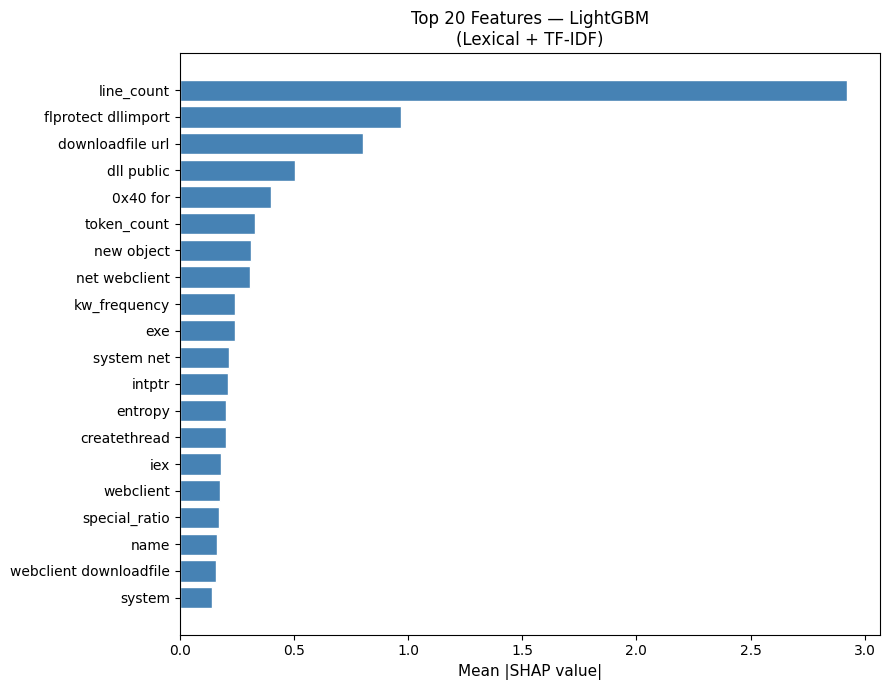

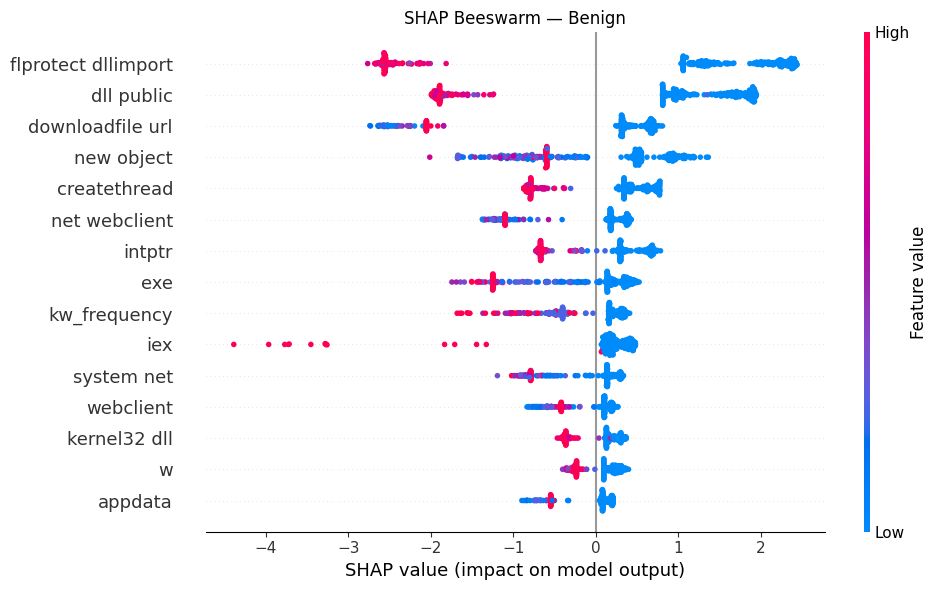

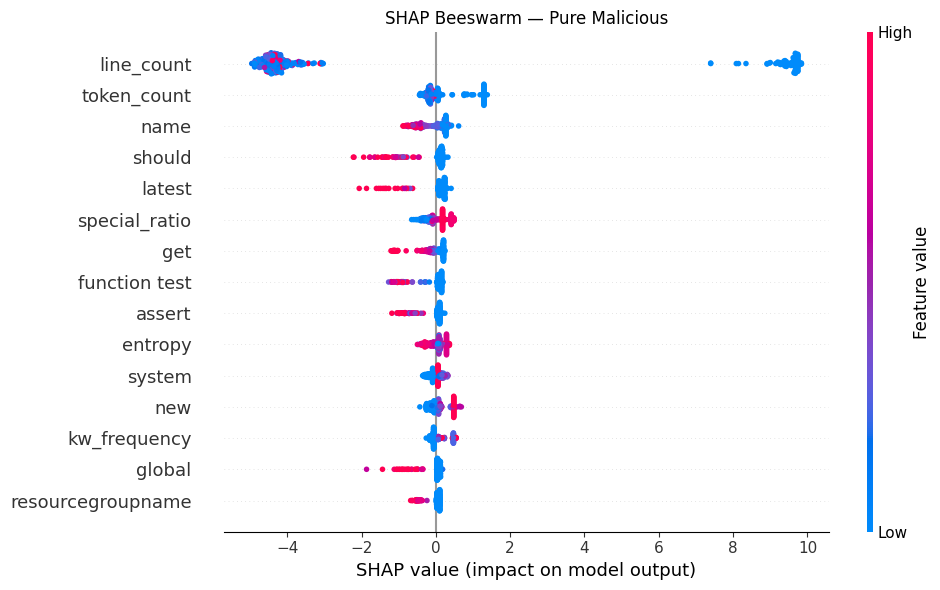

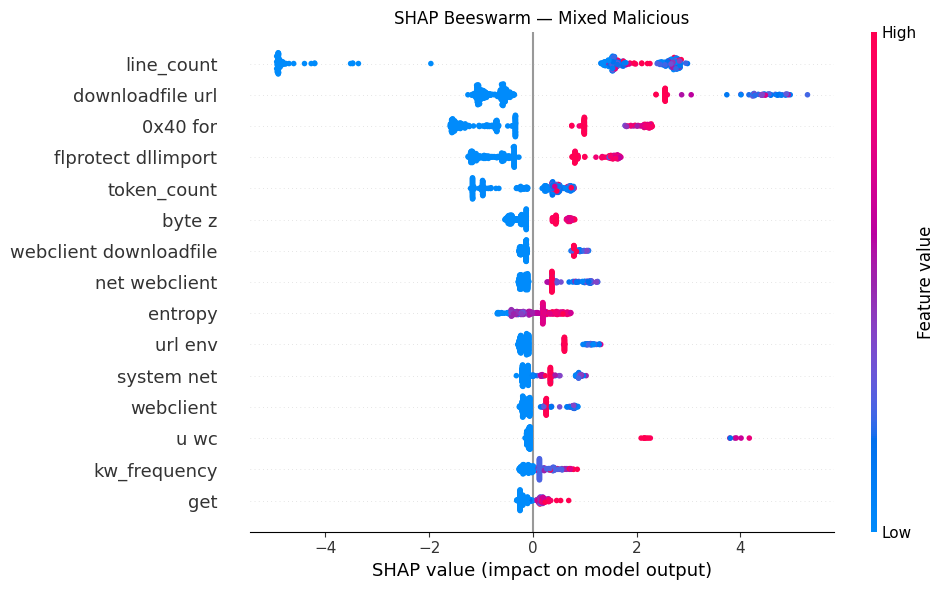

In [17]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
# STEP 13 — SHAP (best tree-based model from PRIMARY experiment)
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
tree_models_set = {'Random Forest', 'LightGBM'}
best_tree_row = (
    primary_df[primary_df['Model'].isin(tree_models_set)]
    .sort_values('Macro F1', ascending=False)
    .iloc[0]
)
shap_model_name = best_tree_row['Model']
shap_cfg_label  = best_tree_row['Configuration']
shap_cfg_key    = best_tree_row['Config Key']

print(f'\nSHAP — Best tree model : {shap_model_name}')
print(f'        Feature config  : {shap_cfg_label}')
print(f'        Macro F1        : {best_tree_row["Macro F1"]:.4f}')

shap_X_train, shap_X_test = feature_configs[shap_cfg_key]
shap_X_tr_d = shap_X_train.toarray() if issparse(shap_X_train) else shap_X_train
shap_X_te_d = shap_X_test.toarray()  if issparse(shap_X_test)  else shap_X_test

shap_m = clone(models[shap_model_name])
shap_m.fit(shap_X_tr_d, y_train)

# Feature names for this config
W2V_NAMES = [f'w2v_{i}' for i in range(100)]
CONFIG_FEATURE_NAMES = {
    'C1 Lexical'        : LEX_FEATURE_NAMES,
    'C2 TF-IDF'         : list(TFIDF_FEATURE_NAMES),
    'C3 Word2Vec'        : W2V_NAMES,
    'C4 Lex+TF-IDF'     : LEX_FEATURE_NAMES + list(TFIDF_FEATURE_NAMES),
    'C5 Lex+Word2Vec'   : LEX_FEATURE_NAMES + W2V_NAMES,
    'C6 TF-IDF+Word2Vec': list(TFIDF_FEATURE_NAMES) + W2V_NAMES,
    'C7 All Three'      : LEX_FEATURE_NAMES + list(TFIDF_FEATURE_NAMES) + W2V_NAMES,
}
shap_feat_names = CONFIG_FEATURE_NAMES[shap_cfg_key]
assert len(shap_feat_names) == shap_X_tr_d.shape[1]

BG_SIZE      = min(500, shap_X_tr_d.shape[0])
bg_idx       = np.random.choice(shap_X_tr_d.shape[0], BG_SIZE, replace=False)
X_background = shap_X_tr_d[bg_idx]
shap_sample  = min(300, shap_X_te_d.shape[0])

print('Computing SHAP values …')
explainer   = shap.TreeExplainer(shap_m, data=X_background, feature_names=shap_feat_names)
shap_values = explainer.shap_values(shap_X_te_d[:shap_sample])
print(f'SHAP output shape: {np.array(shap_values).shape}')

# Global top-20
if isinstance(shap_values, list):
    mean_abs = np.mean(np.abs(np.stack(shap_values, axis=0)), axis=0)
elif np.array(shap_values).ndim == 3:
    mean_abs = np.mean(np.abs(shap_values), axis=2)
else:
    mean_abs = np.abs(shap_values)

mean_imp = mean_abs.mean(axis=0)
top20_idx   = np.argsort(mean_imp)[::-1][:20].tolist()
top20_names = [shap_feat_names[i] for i in top20_idx]
top20_vals  = mean_imp[top20_idx]

plt.figure(figsize=(9, 7))
plt.barh(top20_names[::-1], top20_vals[::-1], color='steelblue', edgecolor='white')
plt.xlabel('Mean |SHAP value|', fontsize=11)
plt.title(f'Top 20 Features — {shap_model_name}\n({shap_cfg_label})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'shap_top20.png'), dpi=200)
plt.show()

# Class-specific beeswarm plots
X_explain = shap_X_te_d[:shap_sample]
beeswarm_fnames = {0:'shap_beeswarm_benign.png',
                   1:'shap_beeswarm_pure_malicious.png',
                   2:'shap_beeswarm_mixed_malicious.png'}

for cls_idx, cls_name in CLASS_NAMES.items():
    if isinstance(shap_values, list):
        sv_cls = shap_values[cls_idx]
    elif np.array(shap_values).ndim == 3:
        sv_cls = shap_values[:, :, cls_idx]
    else:
        sv_cls = shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv_cls, X_explain, feature_names=shap_feat_names,
                      max_display=15, show=False, plot_size=None)
    plt.title(f'SHAP Beeswarm — {cls_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, beeswarm_fnames[cls_idx]), dpi=200)
    plt.show()

shap_config_df = pd.DataFrame([{
    'Model'             : shap_model_name,
    'Configuration'     : shap_cfg_label,
    'Macro F1'          : best_tree_row['Macro F1'],
    'Background samples': BG_SIZE,
    'Explained samples' : shap_sample,
    'Top features shown': 20,
    'SHAP output shape' : str(np.array(shap_values).shape),
    'Feature dim'       : len(shap_feat_names),
}])
shap_config_df.to_csv(os.path.join(OUTPUT_DIR, 'shap_configuration.csv'), index=False)

---
## FINAL PAPER DATA EXPORT

In [18]:
# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =# =
print('\n\n' + '='*50)
print('=== ENVIRONMENT REPORT ===')
print('='*50)
print(env_df.to_string(index=False))

print('\n' + '='*50)
print('=== PRIMARY BEST MODEL ===')
print('='*50)
print(f"  Model         : {best_info['model_name']}")
print(f"  Configuration : {best_info['cfg_label']}")
print(f"  Macro F1      : {best_f1:.4f}")

print('\n' + '='*50)
print('=== CODEBERT RESULTS ===')
print('='*50)
for k, v in bert_metrics.items():
    print(f'  {k}: {v}')
print(f'  Train Time: {bert_train_time:.1f}s')

print('\n' + '='*50)
print('=== MCNEMAR TEST ===')
print('='*50)
for k, v in mcnemar_data.items():
    print(f'  {k}: {v}')

print('\n' + '='*50)
print('=== CV SUMMARY (top 10) ===')
print('='*50)
print(cv_summary[['Configuration','Model','Mean_F1','Std_F1']].head(10).to_string(index=False))

print('\n' + '='*50)
print('=== SHAP CONFIGURATION ===')
print('='*50)
print(shap_config_df.to_string(index=False))

print('\n' + '='*50)
print('=== FEATURE EXTRACTION TIMING ===')
print('='*50)
print(feat_cost_df.to_string(index=False))

print('\nAll CSV and PNG outputs saved to:', OUTPUT_DIR)



=== ENVIRONMENT REPORT ===
       Setting                                Value
      Platform                      Kaggle Notebook
        Python                              3.12.13
            OS Linux-6.12.90+-x86_64-with-glibc2.35
   Random Seed                                   42
         NumPy                                2.0.2
        Pandas                                2.3.3
         SciPy                               1.16.3
  scikit-learn                                1.6.1
        Gensim                                4.4.0
      LightGBM                                4.6.0
       PyTorch                         2.10.0+cu128
  Transformers                                5.0.0
          SHAP                               0.51.0
CUDA Available                                 True
           GPU                             Tesla T4
  CUDA Version                                 12.8

=== PRIMARY BEST MODEL ===
  Model         : LightGBM
  Configuration : Lexical + TF-I

## Notebook Completed